In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
 !wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2026-04-03 15:33:22--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 173.194.202.100, 173.194.202.102, 173.194.202.138, ...
Connecting to drive.google.com (drive.google.com)|173.194.202.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2026-04-03 15:33:22--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.107.132, 2607:f8b0:400e:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.107.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
X = np.array(df[['n_clicks', 'n_visits', 'amount_spent', 'amount_discount',
       'days_since_registration', 'profile_information']])

In [ ]:
X

array([[ 130.        ,   65.        ,  213.90583072,   31.60075063,
         233.        ,  235.        ],
       [ 543.        ,   46.        ,  639.22300377,    5.68917472,
         228.        ,  170.        ],
       [ 520.        ,  102.        , 1157.40276265,  844.32160582,
         247.        ,  409.        ],
       ...,
       [ 375.        ,  111.        ,    0.        ,    0.        ,
          84.        ,  454.        ],
       [ 271.        ,   32.        , 3190.49901844,   78.13306655,
         111.        ,  215.        ],
       [ 814.        ,  123.        , 1394.58904116, 1065.41590223,
         248.        ,  149.        ]])

In [ ]:
# (x-mean)/std
mean = np.mean(X, axis=0)

In [ ]:
std = np.std(X, axis=0)

In [ ]:
(X-mean)/std
idx = np.random.choice(len(X),2)
X[idx]

array([[ 280.        ,  109.        ,  609.22427493,  217.91417238,
         142.        ,  233.        ],
       [ 196.        ,   80.        , 2195.94809671,   69.36148211,
         268.        ,  384.        ]])

In [ ]:
x = np.array([4,5,6,3,2,5,7])
np.argmin(x)

np.int64(4)

# 1. standrdize data
# 2. number of clusters
# 3. initialize random centroids
# 4. distance between points and centroid
# 5. Assignment
# 6. update centroid

In [ ]:
def kmeans(X,k, iter):
  # standardizing
  X =np.array(X)
  mean = np.mean(X,axis=0)
  std = np.std(X, axis=0)
  X = (X-mean)/std

  # initializing random centroids
  idx = np.random.choice(len(X),k)
  centroids = X[idx]

  # define number of iterations
  for iter in range(iter):
    assignment=[]

    # go through every point
    for i in range(len(X)):
      d=[]

      # for every point, we find the distance between the point and the centroid
      for j in range(len(centroids)):
        # distance between point and centroid
        dist = np.linalg.norm(X[i]-centroids[j])
        # storing the distances
        d.append(dist)
      # assigning the point to the nearest centroid
      assign = np.argmin(d)
      assignment.append(assign)

    assignment = np.array(assignment)

    # loop through every centroid and update based on mean of points belonging to it
    for c in range(len(centroids)):
      # identify points assigned to the centroid
      points = X[assignment==c]
      # update the centroid
      centroids[c] = np.mean(points, axis=0)
    # keep on repeating

  return assignment, centroids





















In [ ]:
kmeans(df[['n_clicks', 'n_visits']],2,10)

(array([1, 1, 0, ..., 1, 1, 0]),
 array([[ 0.88553147,  0.84337858],
        [-0.51473967, -0.49023714]]))

In [ ]:
kmeans(df[['n_clicks', 'n_visits']],2,10)

(array([0, 0, 1, ..., 0, 0, 1]),
 array([[-0.51059138, -0.48667368],
        [ 0.8921322 ,  0.85034192]]))

In [ ]:
kmeans(df[['n_clicks', 'n_visits']],2,10)

(array([0, 0, 1, ..., 0, 0, 1]),
 array([[-0.50837731, -0.47476836],
        [ 0.91325947,  0.85288366]]))

In [ ]:
import plotly.express as px
import numpy as np
import pandas as pd

# Select only 2 features
X = df[['n_clicks', 'n_visits']].values

# Run KMeans
assignments, centroids = kmeans(X, 2,10)

# Create dataframe for plotting
plot_df = pd.DataFrame({
    'n_clicks': X[:, 0],
    'n_visits': X[:, 1],
    'Cluster': assignments.astype(str)
})

# Plot clusters
fig = px.scatter(
    plot_df,
    x='n_clicks',
    y='n_visits',
    color='Cluster',
    title="User Segmentation: Clicks vs Visits",
    opacity=0.5
)

# Add centroids
std = np.std(X, axis=0)
mean = np.mean(X, axis=0)
centroids_original = centroids * std + mean
fig.add_scatter(
    x=centroids_original[:, 0],
    y=centroids_original[:, 1],
    mode='markers+text',
    text=[f"C{i}" for i in range(len(centroids_original))],
    textposition="top center",
    marker=dict(size=18, symbol='x'),
    name='Centroids'
)

fig.show()

In [ ]:
centroids_original

array([[574.61031833, 127.53347969],
       [313.54940214,  75.52297042]])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('./E-commerce.csv')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
K_range = range(2, 8)  # silhouette needs at least 2 clusters
inertia = []
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))



Text(0, 0.5, 'Inertia')

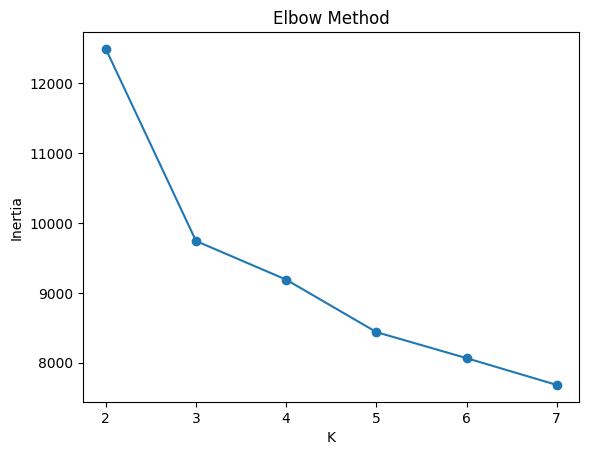

In [ ]:
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

Text(0, 0.5, 'Score')

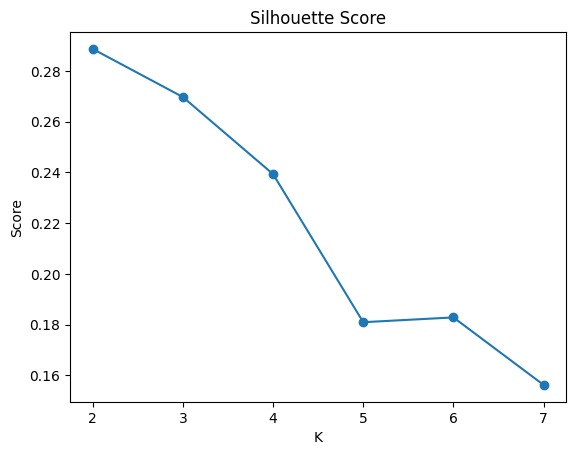

In [ ]:
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

In [ ]:
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df.groupby('cluster').mean()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
cluster,,,,,,,
0,324.852751,252.417476,68.653722,3130.011387,77.356603,197.443366,213.972492
1,2117.466855,585.251058,125.337094,1347.649935,1077.220097,201.726375,198.610719
2,1212.026428,384.282182,89.426257,616.279644,136.160412,202.378517,195.695652
